In [1]:
# ============================================================
# CELLULE 1 — CONFIGURATION
# ============================================================
import os, gc, re, pickle, random, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import psutil
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def mem_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  —  RAM: {mem_gb():.2f} Go")
if DEVICE.type != "cuda":
    print("⚠️ Aucun GPU détecté — active un accélérateur GPU (panneau de droite > Accelerator) puis relance.")

# ------------------------------------------------------------
# DÉCOUVERTE DYNAMIQUE DU DATASET
# ------------------------------------------------------------
def find_dataset_root():
    candidates = [
        Path("/kaggle/input/falldewideoo"),
        Path("/kaggle/input/datasets/imanemokhtari/falldewideoo"),
    ]
    candidates += [p for p in Path("/kaggle/input").glob("*") if p.is_dir()]
    for root in candidates:
        if not root.exists():
            continue
        op_files = list(root.rglob("full_0.pk"))
        if any("/openpose/" in f.as_posix() for f in op_files):
            return root
    raise FileNotFoundError("Dataset FallDeWideo introuvable — vérifie qu'il est attaché (Add Input).")

DATA_ROOT = find_dataset_root()
print("DATA_ROOT:", DATA_ROOT)

def file_number(path):
    m = re.search(r"full_(\d+)\.pk$", str(path))
    return int(m.group(1)) if m else 999

all_pk = list(DATA_ROOT.rglob("full_*.pk"))
normal_openpose  = [p for p in all_pk if p.as_posix().endswith("/openpose/openpose/" + p.name)]
missing_openpose = [p for p in all_pk if p.as_posix().endswith("/missing/missing/openpose/" + p.name)]
openpose_by_number = {file_number(p): p for p in normal_openpose}
openpose_by_number.update({file_number(p): p for p in missing_openpose})
OPENPOSE_FILES = [openpose_by_number[n] for n in sorted(openpose_by_number)]
N_FILES = len(OPENPOSE_FILES)
print("Fichiers OpenPose trouvés :", N_FILES)
assert N_FILES >= 1, "Aucun fichier OpenPose trouvé."
for i, p in enumerate(OPENPOSE_FILES):
    print(f"  full_{i}.pk → {p}")

# ------------------------------------------------------------
# OUTPUT / CACHE
# ------------------------------------------------------------
OUT_DIR = "/kaggle/working/fall_openpose"
CACHE_DIR = "/kaggle/working/cache"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

CLASSES = {"fall": 0, "nfall1": 1, "nfall2": 2}
IDX2CLASS = {v: k for k, v in CLASSES.items()}

BATCH_SIZE  = 128
EPOCHS      = 150          # minimum imposé — pas d'early stopping, la boucle va jusqu'au bout
LR          = 1e-3
WEIGHT_DECAY = 5e-4        # augmenté (était 1e-4) — régularisation L2 plus forte anti-overfitting
LABEL_SMOOTHING = 0.1
DROPOUT     = 0.5
MIXUP_ALPHA = 0.2          # nouveau — active MixUp dans les boucles d'entraînement (anti-overfitting)
N_CLASSES   = 3
N_AFF, N_KPT = 19, 38
IN_CHANNELS = N_AFF + N_KPT   # 57
H, W = 36, 64                # résolution native des heatmaps OpenPose

print("\n✅ Configuration chargée")


Device: cuda  —  RAM: 0.74 Go
DATA_ROOT: /kaggle/input/datasets/imanemokhtari/falldewideoo
Fichiers OpenPose trouvés : 10
  full_0.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/missing/missing/openpose/full_0.pk
  full_1.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_1.pk
  full_2.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_2.pk
  full_3.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_3.pk
  full_4.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_4.pk
  full_5.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_5.pk
  full_6.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_6.pk
  full_7.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_7.pk
  full_8.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_8.pk
  full_9.pk → /kaggle/input/datasets/imanem

In [2]:
# ============================================================
# CELLULE 2 — EXPLORATION DE LA STRUCTURE RÉELLE (1 fichier)
# ============================================================
# But : confirmer les noms de colonnes, la forme de 'aff'/'kpt',
# et trouver la colonne qui permet de dériver le label (fall/nfall1/nfall2)
# avant de construire l'indexation complète (cellule 3).
# On ne charge qu'UN SEUL fichier ici pour rester léger en RAM.

t0 = time.time()
df0 = pd.read_pickle(OPENPOSE_FILES[0])
print(f"Fichier inspecté : {OPENPOSE_FILES[0]}")
print(f"Chargé en {time.time()-t0:.1f}s — RAM: {mem_gb():.2f} Go")
print(f"Shape du DataFrame : {df0.shape}")
print(f"Colonnes : {df0.columns.tolist()}")
print(f"Dtypes :\n{df0.dtypes}")

print("\n--- Aperçu ligne 0 ---")
row0 = df0.iloc[0]
for col in df0.columns:
    val = row0[col]
    if isinstance(val, (np.ndarray, list)):
        arr = np.asarray(val)
        print(f"  {col}: type={type(val).__name__}, shape={arr.shape}, dtype={arr.dtype}")
    else:
        print(f"  {col}: {repr(val)[:150]}")

# ------------------------------------------------------------
# Recherche automatique d'une colonne "chemin" pour dériver le label
# ------------------------------------------------------------
print("\n--- Recherche colonne de type chemin/label ---")
candidate_label_cols = []
for col in df0.columns:
    sample_val = row0[col]
    if isinstance(sample_val, str):
        candidate_label_cols.append(col)
        print(f"  Colonne texte candidate: '{col}' → exemple: {sample_val}")

def guess_label(s):
    s = str(s).lower()
    if "nfall1" in s: return "nfall1"
    if "nfall2" in s: return "nfall2"
    if "fall" in s:   return "fall"
    return None

if candidate_label_cols:
    for col in candidate_label_cols:
        labels_try = df0[col].apply(guess_label)
        n_found = labels_try.notna().sum()
        print(f"\n  Test dérivation label depuis '{col}': {n_found}/{len(df0)} lignes matchées")
        if n_found > 0:
            print(f"  Distribution: {labels_try.value_counts(dropna=False).to_dict()}")
else:
    print("  ⚠️ Aucune colonne texte trouvée — le label n'est peut-être pas dans ce fichier.")

print(f"\nRAM actuelle: {mem_gb():.2f} Go")
del df0, row0
gc.collect()
print("✅ Exploration terminée — mémoire libérée")


Fichier inspecté : /kaggle/input/datasets/imanemokhtari/falldewideoo/missing/missing/openpose/full_0.pk
Chargé en 10.4s — RAM: 1.86 Go
Shape du DataFrame : (4020, 3)
Colonnes : ['kpt', 'aff', 'pic']
Dtypes :
kpt    object
aff    object
pic    object
dtype: object

--- Aperçu ligne 0 ---
  kpt: type=ndarray, shape=(38, 36, 64), dtype=float16
  aff: type=ndarray, shape=(19, 36, 64), dtype=float16
  pic: '/home/sensing/caizhijie/0702-falldewideo/data/20230612_35/falldewideo1_nfall2_lxh_lights_1000_a3_5_rc/t2_2023_06_12_21_26_54_969/2023_06_12_21_26_55_

--- Recherche colonne de type chemin/label ---
  Colonne texte candidate: 'pic' → exemple: /home/sensing/caizhijie/0702-falldewideo/data/20230612_35/falldewideo1_nfall2_lxh_lights_1000_a3_5_rc/t2_2023_06_12_21_26_54_969/2023_06_12_21_26_55_172.jpg

  Test dérivation label depuis 'pic': 4020/4020 lignes matchées
  Distribution: {'nfall2': 1800, 'nfall1': 1200, 'fall': 1020}

RAM actuelle: 1.86 Go
✅ Exploration terminée — mémoire libérée


In [3]:
# ============================================================
# CELLULE 3 — INDEXATION GLOBALE (fichier, ligne, label) — RAM-safe
# ============================================================
INDEX_CACHE = os.path.join(CACHE_DIR, "global_index.pkl")

def guess_label(pic_path):
    s = str(pic_path).lower()
    if "nfall1" in s: return "nfall1"
    if "nfall2" in s: return "nfall2"
    if "fall" in s:   return "fall"
    return None

if os.path.exists(INDEX_CACHE):
    print("Index déjà en cache — chargement...")
    index_df = pd.read_pickle(INDEX_CACHE)
else:
    records = []
    for file_idx, path in enumerate(OPENPOSE_FILES):
        t0 = time.time()
        df = pd.read_pickle(path)
        labels = df["pic"].apply(guess_label)
        n_unmatched = labels.isna().sum()
        if n_unmatched > 0:
            print(f"  ⚠️ full_{file_idx}.pk : {n_unmatched} lignes sans label reconnu (ignorées)")
        for row_idx, lab in enumerate(labels):
            if lab is not None:
                records.append((file_idx, row_idx, lab))
        dt = time.time() - t0
        print(f"full_{file_idx}.pk : {len(df)} lignes lues en {dt:.1f}s — RAM: {mem_gb():.2f} Go")
        del df, labels
        gc.collect()

    index_df = pd.DataFrame(records, columns=["file_idx", "row_idx", "label"])
    index_df["label_id"] = index_df["label"].map(CLASSES)
    index_df.to_pickle(INDEX_CACHE)
    print(f"\nIndex sauvegardé → {INDEX_CACHE}")

print("\n" + "="*50)
print(f"Total échantillons indexés : {len(index_df)}")
counts = index_df["label"].value_counts()
print("Distribution des classes :")
print(counts)
print("\nProportions :")
print((counts / counts.sum() * 100).round(2).astype(str) + " %")
print("="*50)

print("\nRépartition fichiers x classes :")
print(pd.crosstab(index_df["file_idx"], index_df["label"]))

print(f"\nRAM actuelle : {mem_gb():.2f} Go")
print("✅ Index global construit")


full_0.pk : 4020 lignes lues en 0.4s — RAM: 1.86 Go
full_1.pk : 4020 lignes lues en 8.3s — RAM: 1.87 Go
full_2.pk : 4020 lignes lues en 8.7s — RAM: 1.86 Go
full_3.pk : 4020 lignes lues en 8.6s — RAM: 1.86 Go
full_4.pk : 4020 lignes lues en 8.3s — RAM: 1.87 Go
full_5.pk : 4020 lignes lues en 8.5s — RAM: 1.87 Go
full_6.pk : 4020 lignes lues en 8.5s — RAM: 1.87 Go
full_7.pk : 4020 lignes lues en 8.3s — RAM: 1.87 Go
full_8.pk : 4020 lignes lues en 8.3s — RAM: 1.87 Go
full_9.pk : 4020 lignes lues en 8.2s — RAM: 1.87 Go

Index sauvegardé → /kaggle/working/cache/global_index.pkl

Total échantillons indexés : 40200
Distribution des classes :
label
nfall1    15000
nfall2    14300
fall      10900
Name: count, dtype: int64

Proportions :
label
nfall1    37.31 %
nfall2    35.57 %
fall      27.11 %
Name: count, dtype: object

Répartition fichiers x classes :
label     fall  nfall1  nfall2
file_idx                      
0         1020    1200    1800
1         1280    1200    1540
2         1000    

In [4]:
# ============================================================
# CELLULE 4 — CONVERSION EN .npy MEMORY-MAPPÉS (RAM-safe, I/O rapide)
# ============================================================
NPY_DIR = os.path.join(CACHE_DIR, "npy")
os.makedirs(NPY_DIR, exist_ok=True)
manifest_path = os.path.join(NPY_DIR, "manifest.pkl")

if os.path.exists(manifest_path):
    print("Conversion déjà faite — chargement du manifest...")
    with open(manifest_path, "rb") as f:
        manifest = pickle.load(f)
else:
    manifest = []
    global_min, global_max = np.inf, -np.inf

    for file_idx, path in enumerate(OPENPOSE_FILES):
        t0 = time.time()
        df = pd.read_pickle(path)

        labels = df["pic"].apply(guess_label)
        valid_mask = labels.notna()
        if (~valid_mask).sum() > 0:
            df = df[valid_mask].reset_index(drop=True)
            labels = labels[valid_mask].reset_index(drop=True)

        n = len(df)
        aff_stack = np.stack(df["aff"].values).astype(np.float16)
        kpt_stack = np.stack(df["kpt"].values).astype(np.float16)
        X = np.concatenate([aff_stack, kpt_stack], axis=1)
        y = labels.map(CLASSES).values.astype(np.int64)

        global_min = min(global_min, float(X.min()))
        global_max = max(global_max, float(X.max()))

        x_path = os.path.join(NPY_DIR, f"X_{file_idx}.npy")
        y_path = os.path.join(NPY_DIR, f"y_{file_idx}.npy")
        np.save(x_path, X)
        np.save(y_path, y)

        manifest.append({"file_idx": file_idx, "x_path": x_path, "y_path": y_path, "n_samples": n})

        dt = time.time() - t0
        print(f"full_{file_idx}.pk → {x_path}  ({n} échantillons, {dt:.1f}s) — RAM: {mem_gb():.2f} Go")

        del df, aff_stack, kpt_stack, X, y, labels
        gc.collect()

    with open(manifest_path, "wb") as f:
        pickle.dump(manifest, f)
    print(f"\nPlage de valeurs globale des heatmaps : [{global_min:.4f}, {global_max:.4f}]")
    print(f"Manifest sauvegardé → {manifest_path}")

total_samples = sum(m["n_samples"] for m in manifest)
print("\n" + "="*50)
print(f"Total échantillons convertis : {total_samples}")
for m in manifest:
    print(f"  file_idx={m['file_idx']}  n={m['n_samples']}  {os.path.basename(m['x_path'])}")
print("="*50)

X_test = np.load(manifest[0]["x_path"], mmap_mode="r")
print(f"\nTest mmap OK — shape fichier 0: {X_test.shape}, dtype: {X_test.dtype}")
del X_test
gc.collect()

print(f"\nRAM actuelle : {mem_gb():.2f} Go")
print("✅ Conversion en .npy memory-mappés terminée")


full_0.pk → /kaggle/working/cache/npy/X_0.npy  (4020 échantillons, 6.1s) — RAM: 3.98 Go
full_1.pk → /kaggle/working/cache/npy/X_1.npy  (4020 échantillons, 6.0s) — RAM: 3.98 Go
full_2.pk → /kaggle/working/cache/npy/X_2.npy  (4020 échantillons, 6.2s) — RAM: 3.98 Go
full_3.pk → /kaggle/working/cache/npy/X_3.npy  (4020 échantillons, 6.4s) — RAM: 3.98 Go
full_4.pk → /kaggle/working/cache/npy/X_4.npy  (4020 échantillons, 6.4s) — RAM: 3.98 Go
full_5.pk → /kaggle/working/cache/npy/X_5.npy  (4020 échantillons, 6.4s) — RAM: 3.98 Go
full_6.pk → /kaggle/working/cache/npy/X_6.npy  (4020 échantillons, 6.3s) — RAM: 3.98 Go
full_7.pk → /kaggle/working/cache/npy/X_7.npy  (4020 échantillons, 6.4s) — RAM: 3.98 Go
full_8.pk → /kaggle/working/cache/npy/X_8.npy  (4020 échantillons, 6.7s) — RAM: 3.98 Go
full_9.pk → /kaggle/working/cache/npy/X_9.npy  (4020 échantillons, 11.7s) — RAM: 3.98 Go

Plage de valeurs globale des heatmaps : [-1.3330, 1.3018]
Manifest sauvegardé → /kaggle/working/cache/npy/manifest.pkl

In [5]:
# ============================================================
# CELLULE 5 — SPLIT STRATIFIÉ + DATASET AVEC AUGMENTATION (train only) + SAMPLER ÉQUILIBRÉ
# ============================================================
# MODIFIÉ (anti-overfitting) : le Dataset applique désormais, uniquement sur le
# train (augment=True), un bruit gaussien léger, un "channel dropout" (simule des
# points-clés manquants, cohérent avec le taux de missing déjà présent dans les
# données réelles) et un cutout spatial. Val/Test restent inchangés (augment=False).

# ------------------------------------------------------------
# 5.1 Reconstruction de l'index global aligné sur les .npy convertis
# ------------------------------------------------------------
global_records = []
for m in manifest:
    y_arr = np.load(m["y_path"])
    for local_idx, lab_id in enumerate(y_arr):
        global_records.append((m["file_idx"], local_idx, int(lab_id)))

full_index = pd.DataFrame(global_records, columns=["file_idx", "local_idx", "label_id"])
print(f"Total échantillons : {len(full_index)}")
print(full_index["label_id"].map(IDX2CLASS).value_counts())

# ------------------------------------------------------------
# 5.2 Split stratifié 70% train / 15% val / 15% test
# ------------------------------------------------------------
train_idx, temp_idx = train_test_split(
    full_index, test_size=0.30, stratify=full_index["label_id"], random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_idx["label_id"], random_state=SEED
)
train_idx = train_idx.reset_index(drop=True)
val_idx   = val_idx.reset_index(drop=True)
test_idx  = test_idx.reset_index(drop=True)

print(f"\nTrain: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")
for name, split in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    dist = split["label_id"].map(IDX2CLASS).value_counts()
    print(f"{name}: {dist.to_dict()}")

# ------------------------------------------------------------
# 5.3 Dataset avec ouverture mmap paresseuse + augmentation (train only)
# ------------------------------------------------------------
class OpenPoseHeatmapDataset(Dataset):
    def __init__(self, index_df, manifest, augment=False):
        self.index_df = index_df.reset_index(drop=True)
        self.manifest = {m["file_idx"]: m for m in manifest}
        self._mmap_cache = {}
        self.augment = augment   # True uniquement pour le train

    def _get_mmap(self, file_idx):
        if file_idx not in self._mmap_cache:
            m = self.manifest[file_idx]
            self._mmap_cache[file_idx] = np.load(m["x_path"], mmap_mode="r")
        return self._mmap_cache[file_idx]

    def __len__(self):
        return len(self.index_df)

    def _apply_augment(self, x):
        # x: (57, 36, 64) float32 — copie indépendante du mmap (modification sans risque)
        # 1) Bruit gaussien léger — empêche la mémorisation pixel-exacte
        if random.random() < 0.5:
            x = x + np.random.normal(0, 0.03, size=x.shape).astype(np.float32)
        # 2) Channel dropout — simule des points-clés manquants
        if random.random() < 0.3:
            n_drop = random.randint(1, 4)
            drop_idx = np.random.choice(x.shape[0], n_drop, replace=False)
            x[drop_idx] = 0.0
        # 3) Cutout spatial — évite la dépendance à une seule région de l'image
        if random.random() < 0.3:
            h_size, w_size = random.randint(4, 10), random.randint(6, 16)
            h0 = random.randint(0, H - h_size)
            w0 = random.randint(0, W - w_size)
            x[:, h0:h0+h_size, w0:w0+w_size] = 0.0
        return x

    def __getitem__(self, i):
        row = self.index_df.iloc[i]
        X_mmap = self._get_mmap(row["file_idx"])
        x = np.array(X_mmap[row["local_idx"]], dtype=np.float32)
        if self.augment:
            x = self._apply_augment(x)
        y = int(row["label_id"])
        return torch.from_numpy(x), y

train_ds = OpenPoseHeatmapDataset(train_idx, manifest, augment=True)
val_ds   = OpenPoseHeatmapDataset(val_idx, manifest, augment=False)
test_ds  = OpenPoseHeatmapDataset(test_idx, manifest, augment=False)

# ------------------------------------------------------------
# 5.4 Équilibrage des classes — WeightedRandomSampler (train uniquement)
# ------------------------------------------------------------
class_counts = train_idx["label_id"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = train_idx["label_id"].map(lambda c: class_weights[c]).values

print(f"\nPoids par classe (train): {dict(zip(IDX2CLASS.values(), class_weights))}")

sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

# ------------------------------------------------------------
# 5.5 DataLoaders
# ------------------------------------------------------------
NUM_WORKERS = min(4, os.cpu_count() or 2)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
)

print(f"\nBatches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

# ------------------------------------------------------------
# 5.6 Vérification rapide
# ------------------------------------------------------------
t0 = time.time()
xb, yb = next(iter(train_loader))
dt = time.time() - t0
print(f"\nBatch chargé en {dt:.2f}s — shape X: {xb.shape}, dtype: {xb.dtype}")
print(f"Distribution classes dans ce batch : "
      f"{pd.Series(yb.numpy()).map(IDX2CLASS).value_counts().to_dict()}")
print(f"RAM actuelle : {mem_gb():.2f} Go")

del xb, yb
gc.collect()
print("✅ Datasets avec augmentation, sampler et DataLoaders prêts")


Total échantillons : 40200
label_id
nfall1    15000
nfall2    14300
fall      10900
Name: count, dtype: int64

Train: 28140  Val: 6030  Test: 6030
Train: {'nfall1': 10500, 'nfall2': 10010, 'fall': 7630}
Val: {'nfall1': 2250, 'nfall2': 2145, 'fall': 1635}
Test: {'nfall1': 2250, 'nfall2': 2145, 'fall': 1635}

Poids par classe (train): {'fall': np.float64(0.0001310615989515072), 'nfall1': np.float64(9.523809523809524e-05), 'nfall2': np.float64(9.99000999000999e-05)}

Batches — train: 219  val: 48  test: 48

Batch chargé en 2.06s — shape X: torch.Size([128, 57, 36, 64]), dtype: torch.float32
Distribution classes dans ce batch : {'nfall1': 46, 'nfall2': 42, 'fall': 40}
RAM actuelle : 2.44 Go
✅ Datasets avec augmentation, sampler et DataLoaders prêts


In [6]:
# ============================================================
# CELLULE 6 — ARCHITECTURE MobileNetV2 + CBAM + FC (conforme au papier, classifieur réduit)
# ============================================================
from torchvision.models import mobilenet_v2

# ------------------------------------------------------------
# 6.1 Module d'attention CBAM (Convolutional Block Attention Module)
# ------------------------------------------------------------
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        cat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(cat))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ------------------------------------------------------------
# 6.2 MobileNetV2 modifié : conv1 à 57 canaux + CBAM + FC supplémentaire
#     Classifieur réduit (256 -> 128) : moins de capacité de mémorisation (anti-overfitting)
# ------------------------------------------------------------
class MobileNetV2Fall(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=N_CLASSES, dropout=DROPOUT):
        super().__init__()
        base = mobilenet_v2(weights=None)  # from scratch: modalité heatmap != RGB, poids ImageNet non transférables

        old_conv = base.features[0][0]
        new_conv = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=False,
        )
        base.features[0][0] = new_conv

        self.features = base.features
        last_channels = base.last_channel  # 1280

        self.cbam = CBAM(last_channels)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(last_channels, 128),   # 256 -> 128 : anti-overfitting
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = MobileNetV2Fall().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux : {n_params:,}  —  entraînables : {n_trainable:,}")

# ------------------------------------------------------------
# 6.3 Optimizer, scheduler, loss (anti-overfitting sans early stopping)
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

# ------------------------------------------------------------
# 6.4 Test de vitesse : forward+backward sur quelques batches réels
# ------------------------------------------------------------
model.train()
n_warmup, n_timed = 2, 8
it = iter(train_loader)

for _ in range(n_warmup):
    xb, yb = next(it)
    xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
    optimizer.zero_grad()
    with torch.cuda.amp.autocast():
        out = model(xb)
        loss = criterion(out, yb)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

torch.cuda.synchronize()
t0 = time.time()
for _ in range(n_timed):
    xb, yb = next(it)
    xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
    optimizer.zero_grad()
    with torch.cuda.amp.autocast():
        out = model(xb)
        loss = criterion(out, yb)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
torch.cuda.synchronize()
dt_per_batch = (time.time() - t0) / n_timed

est_epoch_time = dt_per_batch * len(train_loader)
print(f"\nTemps/batch (train, AMP) : {dt_per_batch*1000:.1f} ms")
print(f"Estimation temps/epoch (train uniquement, {len(train_loader)} batches) : {est_epoch_time/60:.2f} min")
print(f"Estimation totale sur {EPOCHS} epochs (train only) : {est_epoch_time*EPOCHS/60:.1f} min")
print(f"Mémoire GPU allouée : {torch.cuda.memory_allocated()/1e9:.2f} Go / réservée : {torch.cuda.memory_reserved()/1e9:.2f} Go")

# reset optimizer/scheduler après le test de vitesse
model = MobileNetV2Fall().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

print("\n✅ Modèle, optimizer, scheduler prêts — poids réinitialisés après le test de vitesse")


Paramètres totaux : 2,608,677  —  entraînables : 2,608,677

Temps/batch (train, AMP) : 113.8 ms
Estimation temps/epoch (train uniquement, 219 batches) : 0.42 min
Estimation totale sur 150 epochs (train only) : 62.3 min
Mémoire GPU allouée : 0.13 Go / réservée : 0.50 Go

✅ Modèle, optimizer, scheduler prêts — poids réinitialisés après le test de vitesse


In [7]:
# ============================================================
# CELLULE 6bis — FIX PyTorch 2.6+ (torch.load weights_only)
# ============================================================
def load_ckpt(path):
    # weights_only=False : sans risque ici car on charge uniquement NOS propres checkpoints
    return torch.load(path, map_location=DEVICE, weights_only=False)


In [8]:
# ============================================================
# CELLULE 6ter — MIXUP (anti-overfitting, utilisé par toutes les boucles MobileNet)
# ============================================================
def mixup_batch(x, y, alpha):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x_mixed = lam * x + (1 - lam) * x[perm]
    return x_mixed, y, y[perm], lam

print("✅ MixUp prêt (MIXUP_ALPHA =", MIXUP_ALPHA, ")")


✅ MixUp prêt (MIXUP_ALPHA = 0.2 )


In [9]:
# ============================================================
# CELLULE 7 — BOUCLE D'ENTRAÎNEMENT COMPLÈTE (sans early stopping, avec MixUp)
# ============================================================
CKPT_BEST = os.path.join(OUT_DIR, "best_model.pt")
CKPT_LAST = os.path.join(OUT_DIR, "last_model.pt")

history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss": [], "val_acc": [], "val_f1": [],
    "lr": [],
}

def run_epoch(loader, train_mode):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss, n_samples = 0.0, 0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            if train_mode:
                xb_mix, y_a, y_b, lam = mixup_batch(xb, yb, MIXUP_ALPHA)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    out = model(xb_mix)
                    loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with torch.cuda.amp.autocast():
                    out = model(xb)
                    loss = criterion(out, yb)

            bs = yb.size(0)
            total_loss += loss.item() * bs
            n_samples += bs
            preds = out.argmax(dim=1)
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / n_samples
    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1

print(f"Début de l'entraînement — {EPOCHS} epochs, pas d'early stopping\n")
best_val_f1 = -1.0
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc, train_f1 = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train_mode=False)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    dt = time.time() - t0

    is_best = val_f1 > best_val_f1
    if is_best:
        best_val_f1 = val_f1
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "val_f1": float(val_f1), "val_acc": float(val_acc),
        }, CKPT_BEST)

    flag = " ⭐ best" if is_best else ""
    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | "
          f"lr={current_lr:.6f} | {dt:.1f}s{flag}")

    torch.save({
        "epoch": epoch, "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history,
    }, CKPT_LAST)

total_time = time.time() - t_start
print(f"\n✅ Entraînement terminé — {EPOCHS} epochs en {total_time/60:.1f} min "
      f"({total_time/EPOCHS:.1f}s/epoch en moyenne)")
print(f"Meilleur val_f1 (macro) : {best_val_f1:.4f}")

with open(os.path.join(OUT_DIR, "history.pkl"), "wb") as f:
    pickle.dump(history, f)
print(f"Historique sauvegardé → {OUT_DIR}/history.pkl")


Début de l'entraînement — 150 epochs, pas d'early stopping

Epoch   1/150 | train_loss=0.9430 train_acc=0.4680 train_f1=0.4660 | val_loss=0.8134 val_acc=0.6652 val_f1=0.6570 | lr=0.001000 | 53.4s ⭐ best
Epoch   2/150 | train_loss=0.7789 train_acc=0.5198 train_f1=0.5194 | val_loss=0.6713 val_acc=0.7846 val_f1=0.7850 | lr=0.001000 | 43.0s ⭐ best
Epoch   3/150 | train_loss=0.7107 train_acc=0.5952 train_f1=0.5953 | val_loss=0.6309 val_acc=0.8275 val_f1=0.8265 | lr=0.000999 | 42.4s ⭐ best
Epoch   4/150 | train_loss=0.6822 train_acc=0.5911 train_f1=0.5911 | val_loss=0.5780 val_acc=0.8648 val_f1=0.8653 | lr=0.000998 | 41.8s ⭐ best
Epoch   5/150 | train_loss=0.6527 train_acc=0.6056 train_f1=0.6056 | val_loss=0.5322 val_acc=0.8743 val_f1=0.8757 | lr=0.000997 | 42.4s ⭐ best
Epoch   6/150 | train_loss=0.6368 train_acc=0.6213 train_f1=0.6213 | val_loss=0.5103 val_acc=0.8914 val_f1=0.8917 | lr=0.000996 | 42.1s ⭐ best
Epoch   7/150 | train_loss=0.6106 train_acc=0.6308 train_f1=0.6308 | val_loss=0.53

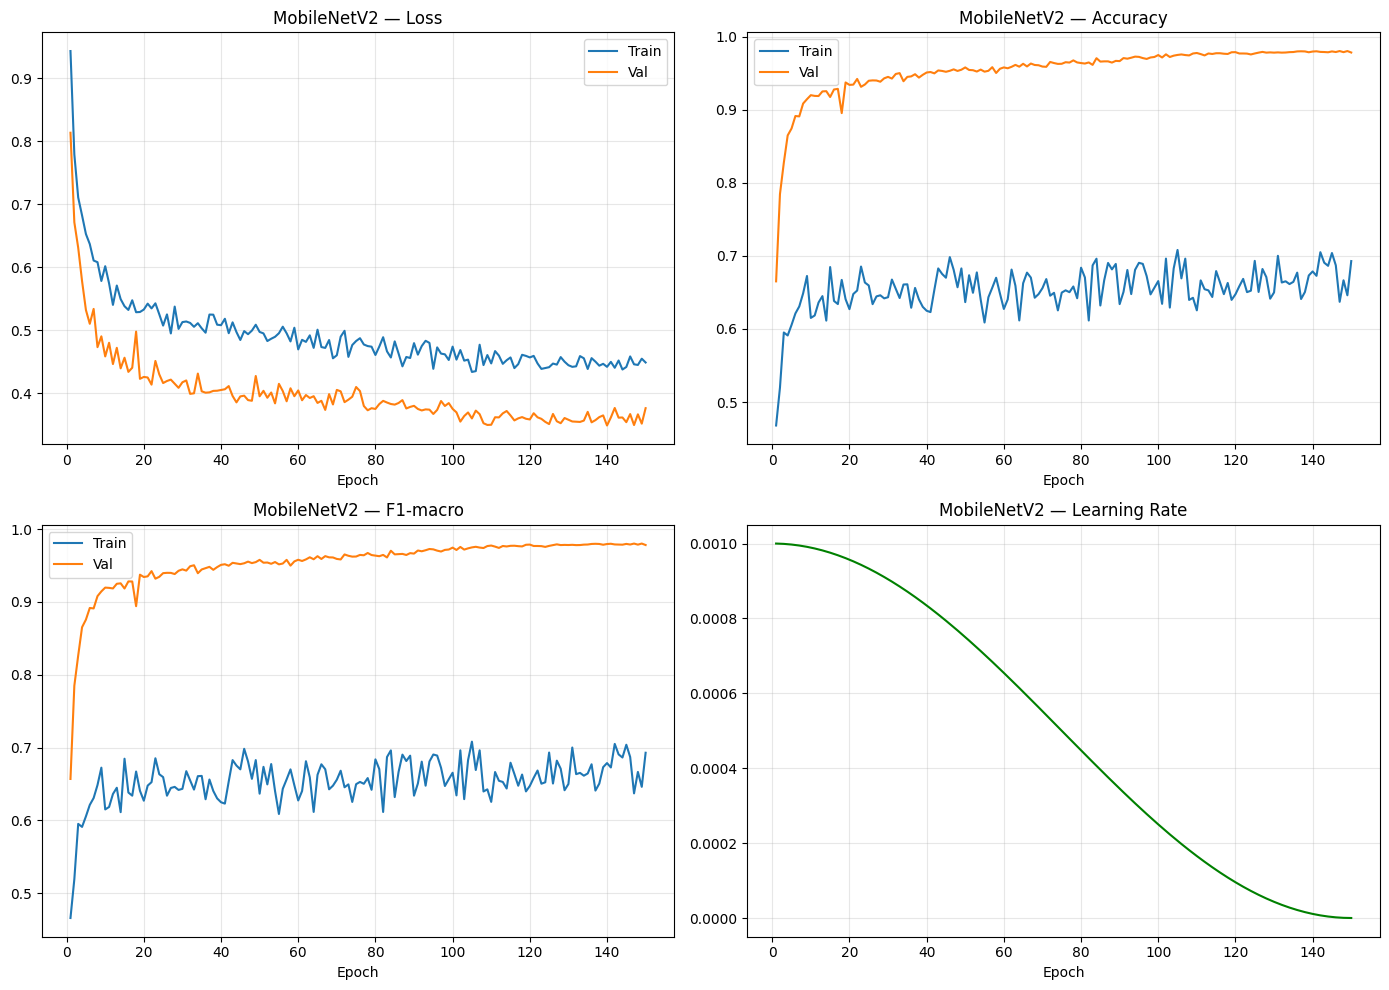

Figure sauvegardée → /kaggle/working/fall_openpose/MobileNetV2_.png

✅ train_acc ne plafonne jamais à 1.0000 — augmentation/régularisation efficaces.
Écart moyen train_acc - val_acc sur les 30 dernières epochs : -0.3092
val_f1 sur les 30 dernières epochs : 0.9785


In [10]:
# ============================================================
# CELLULE 8 — COURBES D'ENTRAÎNEMENT (MobileNetV2)
# ============================================================
def plot_history(history, title_prefix=""):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0,0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0,0].plot(epochs_range, history["val_loss"], label="Val")
    axes[0,0].set_title(f"{title_prefix}Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(epochs_range, history["train_acc"], label="Train")
    axes[0,1].plot(epochs_range, history["val_acc"], label="Val")
    axes[0,1].set_title(f"{title_prefix}Accuracy"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    axes[1,0].plot(epochs_range, history["train_f1"], label="Train")
    axes[1,0].plot(epochs_range, history["val_f1"], label="Val")
    axes[1,0].set_title(f"{title_prefix}F1-macro"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    axes[1,1].plot(epochs_range, history["lr"], color="green")
    axes[1,1].set_title(f"{title_prefix}Learning Rate"); axes[1,1].set_xlabel("Epoch"); axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    fname = os.path.join(OUT_DIR, f"{title_prefix.strip().replace(' ','_').replace('—','') or 'curves'}.png")
    plt.savefig(fname, dpi=120)
    plt.show()
    print(f"Figure sauvegardée → {fname}")

plot_history(history, title_prefix="MobileNetV2 — ")

gap_acc = np.array(history["train_acc"]) - np.array(history["val_acc"])
first_perfect = next((i+1 for i, v in enumerate(history["train_acc"]) if v >= 0.999), None)
if first_perfect:
    print(f"\n⚠️ train_acc atteint ~1.0000 dès l'epoch {first_perfect}.")
else:
    print(f"\n✅ train_acc ne plafonne jamais à 1.0000 — augmentation/régularisation efficaces.")
print(f"Écart moyen train_acc - val_acc sur les 30 dernières epochs : {gap_acc[-30:].mean():.4f}")
print(f"val_f1 sur les 30 dernières epochs : {np.mean(history['val_f1'][-30:]):.4f}")



MobileNetV2 — Évaluation TEST SET (checkpoint epoch 149)
Test accuracy : 0.9788   Test F1-macro : 0.9787

              precision    recall  f1-score   support

        fall     0.9882    0.9694    0.9787      1635
      nfall1     0.9862    0.9822    0.9842      2250
      nfall2     0.9643    0.9823    0.9732      2145

    accuracy                         0.9788      6030
   macro avg     0.9795    0.9780    0.9787      6030
weighted avg     0.9789    0.9788    0.9788      6030



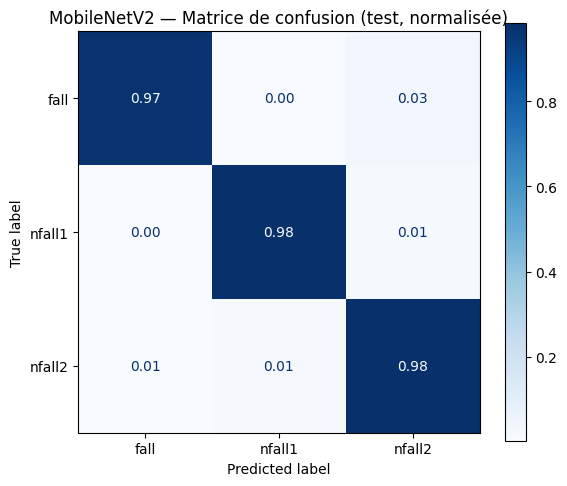

In [11]:
# ============================================================
# CELLULE 9 — ÉVALUATION SUR TEST SET (meilleur checkpoint, MobileNetV2)
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_on_test(model, ckpt_path, loader, name=""):
    ckpt = load_ckpt(ckpt_path)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(yb.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = (all_preds == all_labels).mean()
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    report = classification_report(all_labels, all_preds, target_names=list(CLASSES.keys()), digits=4)

    print(f"\n{'='*50}\n{name} — Évaluation TEST SET (checkpoint epoch {ckpt['epoch']})\n{'='*50}")
    print(f"Test accuracy : {acc:.4f}   Test F1-macro : {f1_macro:.4f}\n")
    print(report)

    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay.from_predictions(
        all_labels, all_preds, display_labels=list(CLASSES.keys()),
        ax=ax, cmap="Blues", normalize="true", values_format=".2f"
    )
    ax.set_title(f"{name} — Matrice de confusion (test, normalisée)")
    plt.tight_layout()
    fname = os.path.join(OUT_DIR, f"confmat_{name.replace(' ','_')}.png")
    plt.savefig(fname, dpi=120)
    plt.show()

    return {"test_acc": acc, "test_f1_macro": f1_macro, "report": report,
            "y_true": all_labels, "y_pred": all_preds}

test_metrics_v2 = evaluate_on_test(model, CKPT_BEST, test_loader, name="MobileNetV2")


In [12]:
# ============================================================
# CELLULE 10 — INFRA GÉNÉRIQUE RÉUTILISABLE (V3, V4) + install timm
# ============================================================
import subprocess, sys
try:
    import timm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "timm"], check=True)
    import timm
print("timm version:", timm.__version__)

# ------------------------------------------------------------
# 10.1 Wrapper générique : backbone timm (any arch) + CBAM + FC (classifieur réduit)
# ------------------------------------------------------------
class GenericFallNet(nn.Module):
    def __init__(self, backbone_name, in_channels=IN_CHANNELS, num_classes=N_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=False, in_chans=in_channels,
            num_classes=0, global_pool=""
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, H, W)
            feat = self.backbone(dummy)
        feat_channels = feat.shape[1]
        print(f"  [{backbone_name}] feature map: {tuple(feat.shape[1:])}")

        self.cbam = CBAM(feat_channels)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_channels, 128),   # 256 -> 128 : anti-overfitting, cohérent avec cellule 6
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# ------------------------------------------------------------
# 10.2 Boucle d'entraînement générique (avec MixUp, identique en logique à la cellule 7)
# ------------------------------------------------------------
def run_epoch_generic(loader, model, optimizer, criterion, scaler, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, n_samples = 0.0, 0
    all_preds, all_labels = [], []
    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            if train_mode:
                xb_mix, y_a, y_b, lam = mixup_batch(xb, yb, MIXUP_ALPHA)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    out = model(xb_mix)
                    loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer); scaler.update()
            else:
                with torch.cuda.amp.autocast():
                    out = model(xb); loss = criterion(out, yb)
            bs = yb.size(0)
            total_loss += loss.item() * bs
            n_samples += bs
            all_preds.append(out.argmax(dim=1).detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())
    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    return (total_loss/n_samples, (all_preds==all_labels).mean(),
            f1_score(all_labels, all_preds, average="macro"))

def train_full(model, name, epochs=EPOCHS, lr=LR):
    ckpt_best = os.path.join(OUT_DIR, f"best_{name}.pt")
    ckpt_last = os.path.join(OUT_DIR, f"last_{name}.pt")
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler()

    hist = {"train_loss":[], "train_acc":[], "train_f1":[],
            "val_loss":[], "val_acc":[], "val_f1":[], "lr":[]}
    best_val_f1 = -1.0
    print(f"\n{'='*60}\nEntraînement : {name} — {epochs} epochs\n{'='*60}")
    t_start = time.time()
    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc, tr_f1 = run_epoch_generic(train_loader, model, optimizer, criterion, scaler, True)
        vl_loss, vl_acc, vl_f1 = run_epoch_generic(val_loader, model, optimizer, criterion, scaler, False)
        scheduler.step()
        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc); hist["train_f1"].append(tr_f1)
        hist["val_loss"].append(vl_loss); hist["val_acc"].append(vl_acc); hist["val_f1"].append(vl_f1)
        hist["lr"].append(optimizer.param_groups[0]["lr"])
        is_best = vl_f1 > best_val_f1
        if is_best:
            best_val_f1 = vl_f1
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "val_f1": float(vl_f1), "val_acc": float(vl_acc)}, ckpt_best)
        dt = time.time() - t0
        if epoch % 10 == 0 or epoch == 1 or epoch == epochs or is_best:
            flag = " ⭐ best" if is_best else ""
            print(f"[{name}] Epoch {epoch:3d}/{epochs} | train_f1={tr_f1:.4f} | "
                  f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f} val_f1={vl_f1:.4f} | {dt:.1f}s{flag}")
        torch.save({"epoch": epoch, "model_state": model.state_dict()}, ckpt_last)

    total_time = time.time() - t_start
    print(f"\n✅ {name} terminé — {epochs} epochs en {total_time/60:.1f} min "
          f"({total_time/epochs:.1f}s/epoch) — meilleur val_f1: {best_val_f1:.4f}")
    with open(os.path.join(OUT_DIR, f"history_{name}.pkl"), "wb") as f:
        pickle.dump(hist, f)
    return hist, ckpt_best, best_val_f1

# ------------------------------------------------------------
# 10.3 Registre global des résultats (pour la comparaison finale)
# ------------------------------------------------------------
all_results = {}
all_results["MobileNetV2"] = {
    "history": history,
    "ckpt_best": CKPT_BEST,
    "best_val_f1": best_val_f1,
    "n_params": n_params,
    **test_metrics_v2,
}
print("\n✅ Infra générique prête — MobileNetV2 enregistré dans all_results")


timm version: 1.0.26

✅ Infra générique prête — MobileNetV2 enregistré dans all_results


  [mobilenetv3_large_100] feature map: (1280, 2, 2)
MobileNetV3 — paramètres : 4,579,061

Entraînement : MobileNetV3 — 150 epochs
[MobileNetV3] Epoch   1/150 | train_f1=0.4635 | val_loss=0.7532 val_acc=0.7285 val_f1=0.7254 | 45.9s ⭐ best
[MobileNetV3] Epoch   2/150 | train_f1=0.5472 | val_loss=0.6570 val_acc=0.8056 val_f1=0.8043 | 42.1s ⭐ best
[MobileNetV3] Epoch   3/150 | train_f1=0.5709 | val_loss=0.5909 val_acc=0.8365 val_f1=0.8383 | 42.4s ⭐ best
[MobileNetV3] Epoch   4/150 | train_f1=0.5992 | val_loss=0.5258 val_acc=0.8771 val_f1=0.8774 | 42.2s ⭐ best
[MobileNetV3] Epoch   5/150 | train_f1=0.6473 | val_loss=0.5248 val_acc=0.8828 val_f1=0.8820 | 42.2s ⭐ best
[MobileNetV3] Epoch   6/150 | train_f1=0.5920 | val_loss=0.4981 val_acc=0.8945 val_f1=0.8936 | 42.1s ⭐ best
[MobileNetV3] Epoch   7/150 | train_f1=0.6011 | val_loss=0.4778 val_acc=0.9053 val_f1=0.9051 | 42.3s ⭐ best
[MobileNetV3] Epoch   8/150 | train_f1=0.6201 | val_loss=0.4667 val_acc=0.9101 val_f1=0.9096 | 42.4s ⭐ best
[Mobil

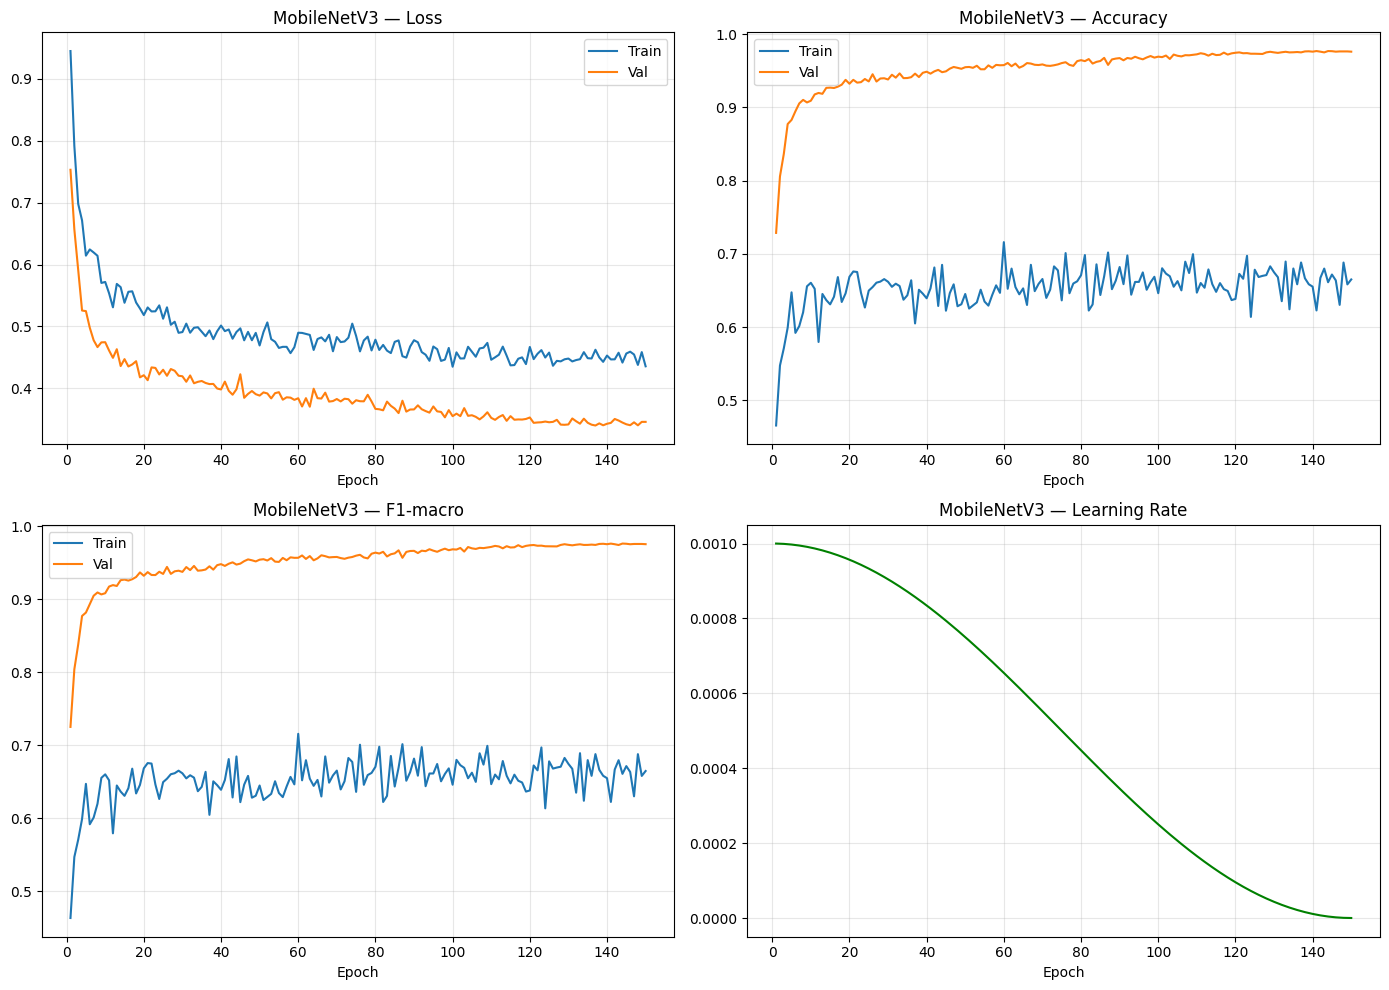

Figure sauvegardée → /kaggle/working/fall_openpose/MobileNetV3_.png

MobileNetV3 — Évaluation TEST SET (checkpoint epoch 144)
Test accuracy : 0.9788   Test F1-macro : 0.9784

              precision    recall  f1-score   support

        fall     0.9814    0.9688    0.9751      1635
      nfall1     0.9883    0.9791    0.9837      2250
      nfall2     0.9671    0.9860    0.9765      2145

    accuracy                         0.9788      6030
   macro avg     0.9789    0.9780    0.9784      6030
weighted avg     0.9789    0.9788    0.9788      6030



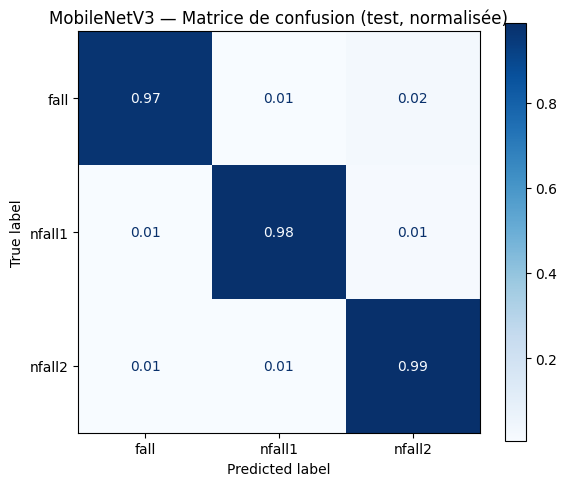

✅ MobileNetV3 enregistré, mémoire GPU libérée


In [13]:
# ============================================================
# CELLULE 11 — MobileNetV3 (large) — build + train + eval
# ============================================================
model_v3 = GenericFallNet("mobilenetv3_large_100").to(DEVICE)
n_params_v3 = sum(p.numel() for p in model_v3.parameters())
print(f"MobileNetV3 — paramètres : {n_params_v3:,}")

history_v3, ckpt_best_v3, best_val_f1_v3 = train_full(model_v3, "MobileNetV3", epochs=EPOCHS, lr=LR)
plot_history(history_v3, title_prefix="MobileNetV3 — ")
test_metrics_v3 = evaluate_on_test(model_v3, ckpt_best_v3, test_loader, name="MobileNetV3")

all_results["MobileNetV3"] = {
    "history": history_v3, "ckpt_best": ckpt_best_v3,
    "best_val_f1": best_val_f1_v3, "n_params": n_params_v3, **test_metrics_v3,
}

del model_v3
gc.collect(); torch.cuda.empty_cache()
print("✅ MobileNetV3 enregistré, mémoire GPU libérée")


  [mobilenetv4_conv_small] feature map: (1280, 2, 2)
MobileNetV4 — paramètres : 2,877,829

Entraînement : MobileNetV4 — 150 epochs
[MobileNetV4] Epoch   1/150 | train_f1=0.4860 | val_loss=0.7571 val_acc=0.7415 val_f1=0.7411 | 43.1s ⭐ best
[MobileNetV4] Epoch   2/150 | train_f1=0.5625 | val_loss=0.5961 val_acc=0.8406 val_f1=0.8397 | 41.2s ⭐ best
[MobileNetV4] Epoch   3/150 | train_f1=0.5983 | val_loss=0.5368 val_acc=0.8816 val_f1=0.8822 | 41.4s ⭐ best
[MobileNetV4] Epoch   4/150 | train_f1=0.6148 | val_loss=0.5173 val_acc=0.8944 val_f1=0.8948 | 41.3s ⭐ best
[MobileNetV4] Epoch   5/150 | train_f1=0.6285 | val_loss=0.5021 val_acc=0.8965 val_f1=0.8968 | 41.5s ⭐ best
[MobileNetV4] Epoch   7/150 | train_f1=0.6378 | val_loss=0.4703 val_acc=0.9128 val_f1=0.9123 | 40.8s ⭐ best
[MobileNetV4] Epoch   8/150 | train_f1=0.6153 | val_loss=0.4657 val_acc=0.9163 val_f1=0.9159 | 41.8s ⭐ best
[MobileNetV4] Epoch   9/150 | train_f1=0.6406 | val_loss=0.4473 val_acc=0.9327 val_f1=0.9325 | 41.6s ⭐ best
[Mobi

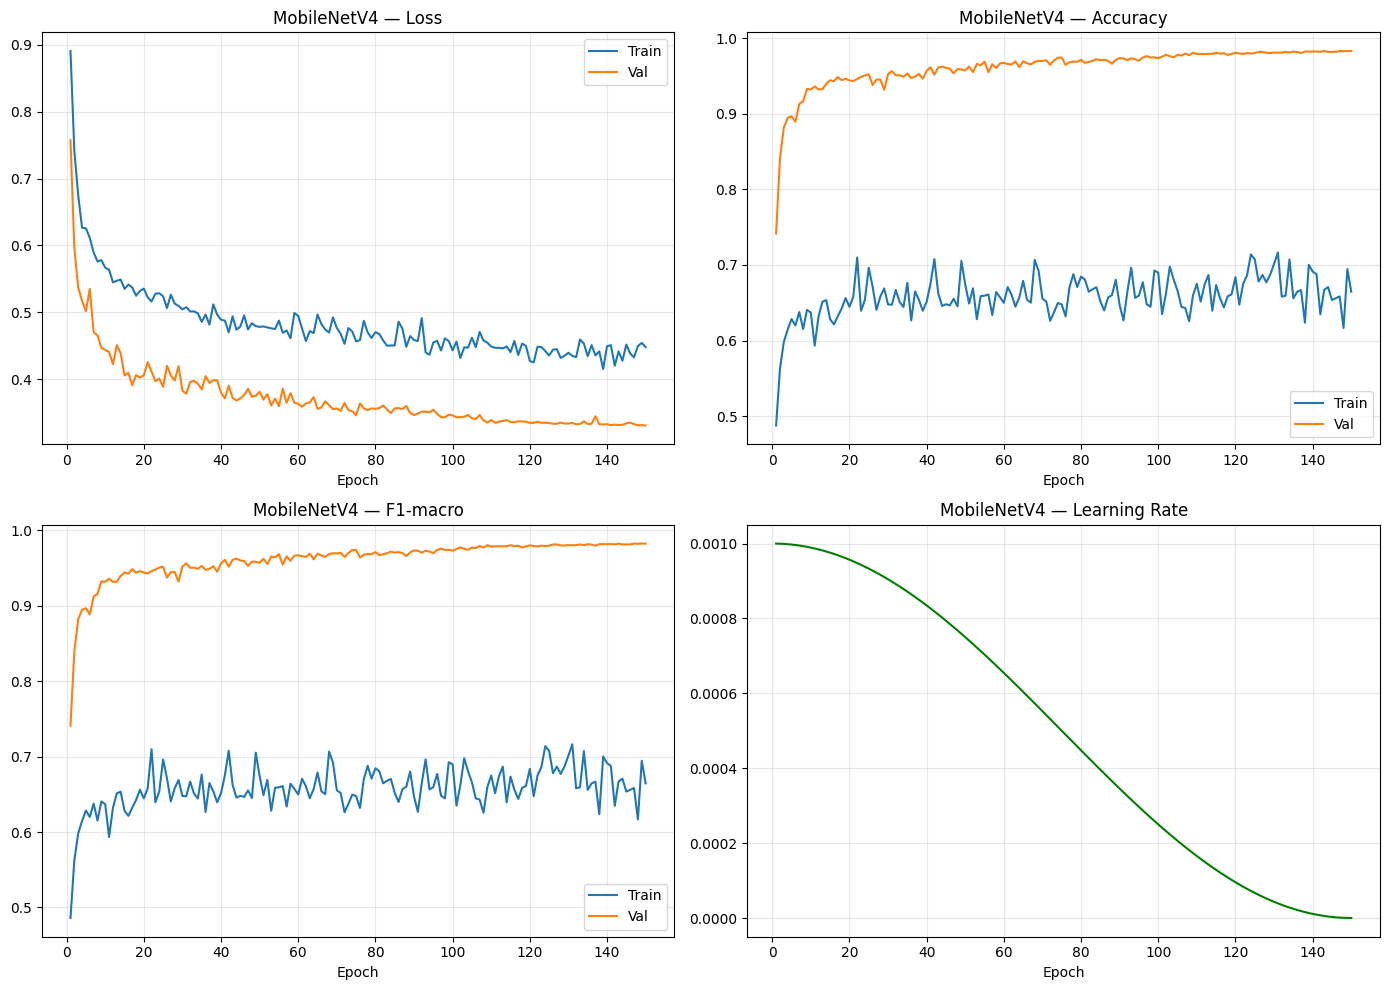

Figure sauvegardée → /kaggle/working/fall_openpose/MobileNetV4_.png

MobileNetV4 — Évaluation TEST SET (checkpoint epoch 147)
Test accuracy : 0.9818   Test F1-macro : 0.9817

              precision    recall  f1-score   support

        fall     0.9840    0.9786    0.9813      1635
      nfall1     0.9892    0.9804    0.9848      2250
      nfall2     0.9724    0.9855    0.9789      2145

    accuracy                         0.9818      6030
   macro avg     0.9819    0.9815    0.9817      6030
weighted avg     0.9818    0.9818    0.9818      6030



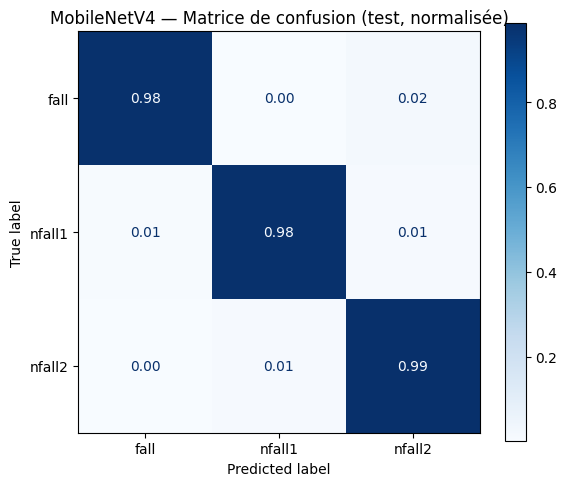

✅ MobileNetV4 enregistré, mémoire GPU libérée


In [14]:
# ============================================================
# CELLULE 12 — MobileNetV4 (conv_small) — build + train + eval
# ============================================================
model_v4 = GenericFallNet("mobilenetv4_conv_small").to(DEVICE)
n_params_v4 = sum(p.numel() for p in model_v4.parameters())
print(f"MobileNetV4 — paramètres : {n_params_v4:,}")

history_v4, ckpt_best_v4, best_val_f1_v4 = train_full(model_v4, "MobileNetV4", epochs=EPOCHS, lr=LR)
plot_history(history_v4, title_prefix="MobileNetV4 — ")
test_metrics_v4 = evaluate_on_test(model_v4, ckpt_best_v4, test_loader, name="MobileNetV4")

all_results["MobileNetV4"] = {
    "history": history_v4, "ckpt_best": ckpt_best_v4,
    "best_val_f1": best_val_f1_v4, "n_params": n_params_v4, **test_metrics_v4,
}

del model_v4
gc.collect(); torch.cuda.empty_cache()
print("✅ MobileNetV4 enregistré, mémoire GPU libérée")


     Modèle    Params Best val_f1 Test accuracy Test F1-macro
MobileNetV2 2,608,677      0.9802        0.9788        0.9787
MobileNetV3 4,579,061      0.9766        0.9788        0.9784
MobileNetV4 2,877,829      0.9826        0.9818        0.9817


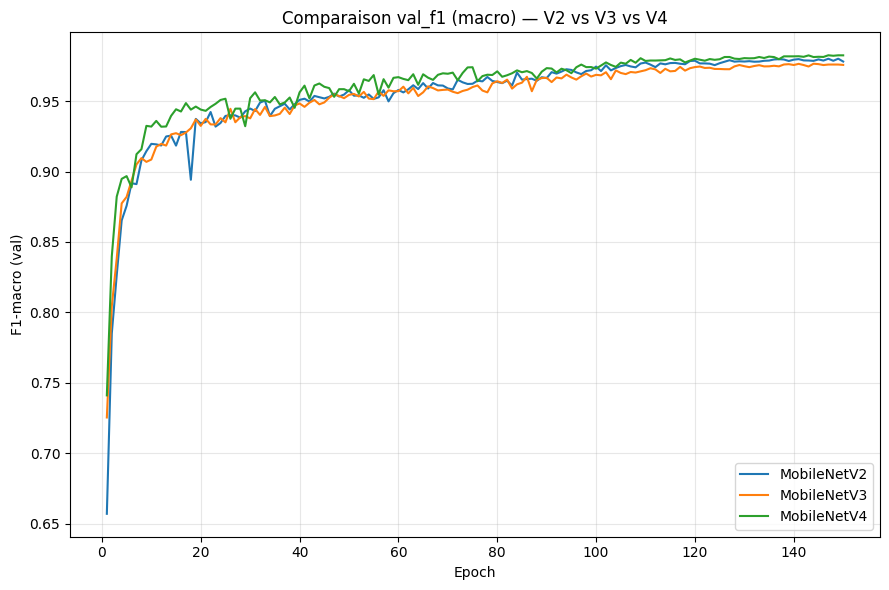

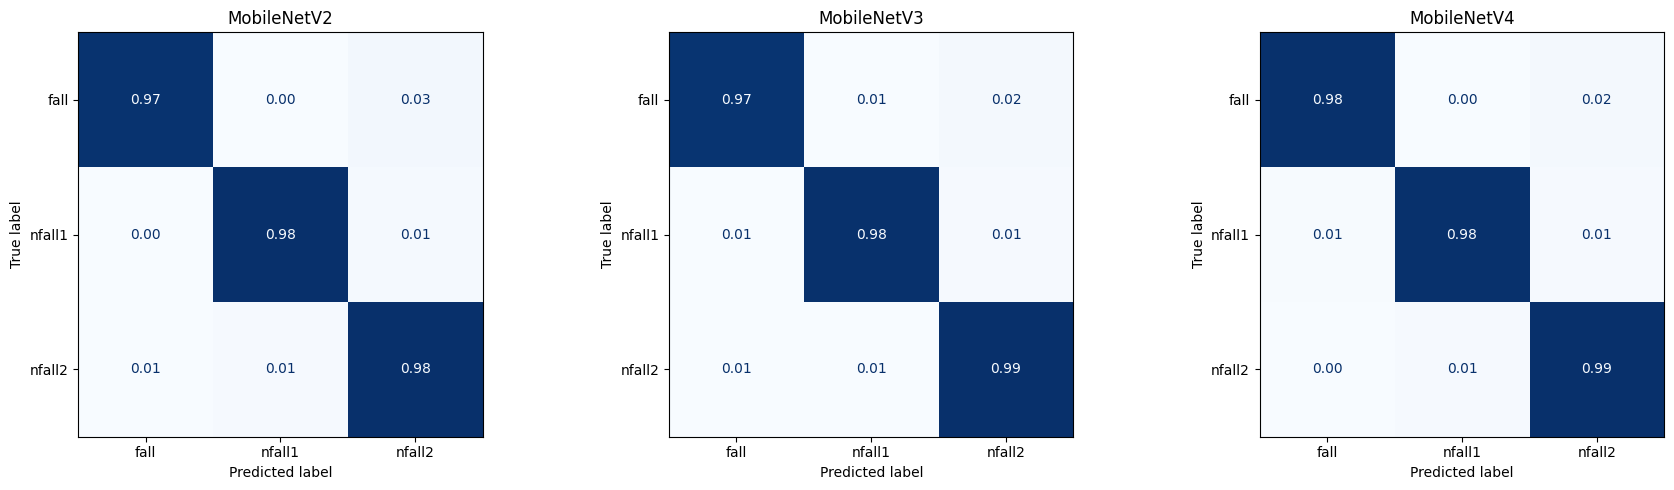


✅ Comparaison terminée — résultats sauvegardés dans /kaggle/working/fall_openpose


In [15]:
# ============================================================
# CELLULE 13 — COMPARAISON FINALE (V2 vs V3 vs V4)
# ============================================================
summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        "Modèle": name,
        "Params": f"{res['n_params']:,}",
        "Best val_f1": f"{res['best_val_f1']:.4f}",
        "Test accuracy": f"{res['test_acc']:.4f}",
        "Test F1-macro": f"{res['test_f1_macro']:.4f}",
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(OUT_DIR, "comparison_summary.csv"), index=False)

plt.figure(figsize=(9,6))
for name, res in all_results.items():
    plt.plot(range(1, len(res["history"]["val_f1"])+1), res["history"]["val_f1"], label=name)
plt.title("Comparaison val_f1 (macro) — V2 vs V3 vs V4")
plt.xlabel("Epoch"); plt.ylabel("F1-macro (val)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparison_val_f1.png"), dpi=120)
plt.show()

fig, axes = plt.subplots(1, len(all_results), figsize=(6*len(all_results), 5))
if len(all_results) == 1: axes = [axes]
for ax, (name, res) in zip(axes, all_results.items()):
    ConfusionMatrixDisplay.from_predictions(
        res["y_true"], res["y_pred"], display_labels=list(CLASSES.keys()),
        ax=ax, cmap="Blues", normalize="true", values_format=".2f", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparison_confmats.png"), dpi=120)
plt.show()

print(f"\n✅ Comparaison terminée — résultats sauvegardés dans {OUT_DIR}")


In [16]:
# ============================================================
# CELLULE 13bis — ÉVALUATION "PROPRE" DU TRAIN (sans MixUp, sans Dropout actif)
# ============================================================
# But : donner une vraie mesure de train_acc/train_f1 comparable à val/test,
# en désactivant Dropout (model.eval()) et sans MixUp — uniquement pour le
# rapport / la comparaison. Ne réentraîne rien : réutilise les meilleurs
# checkpoints déjà sauvegardés. Doit s'exécuter AVANT la cellule 16bis
# (nettoyage disque) puisque les heatmaps .npy sont encore nécessaires ici.

train_eval_ds = OpenPoseHeatmapDataset(train_idx, manifest, augment=False)
train_eval_loader = DataLoader(
    train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

def evaluate_clean(model_ctor, ckpt_path, name):
    m = model_ctor().to(DEVICE)
    ckpt = load_ckpt(ckpt_path)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in train_eval_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                out = m(xb)
            all_preds.append(out.argmax(dim=1).cpu().numpy())
            all_labels.append(yb.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average="macro")
    del m
    gc.collect(); torch.cuda.empty_cache()
    print(f"  {name}: train_acc (propre) = {acc:.4f}  |  train_f1 (propre) = {f1:.4f}")
    return acc, f1

print("Calcul du train_acc/train_f1 'propre' (sans MixUp, sans Dropout actif)...\n")
clean_train_results = {}
clean_train_results["MobileNetV2"] = evaluate_clean(
    lambda: MobileNetV2Fall(), all_results["MobileNetV2"]["ckpt_best"], "MobileNetV2")
clean_train_results["MobileNetV3"] = evaluate_clean(
    lambda: GenericFallNet("mobilenetv3_large_100"), all_results["MobileNetV3"]["ckpt_best"], "MobileNetV3")
clean_train_results["MobileNetV4"] = evaluate_clean(
    lambda: GenericFallNet("mobilenetv4_conv_small"), all_results["MobileNetV4"]["ckpt_best"], "MobileNetV4")

print(f"\n{'Modèle':<12} {'Train acc (propre)':>20} {'Train F1 (propre)':>20} {'Val F1':>10} {'Test F1':>10}")
for name in ["MobileNetV2", "MobileNetV3", "MobileNetV4"]:
    acc, f1 = clean_train_results[name]
    r = all_results[name]
    print(f"{name:<12} {acc:>20.4f} {f1:>20.4f} {r['best_val_f1']:>10.4f} {r['test_f1_macro']:>10.4f}")

print("\n✅ Si train_f1 (propre) ≈ val_f1 ≈ test_f1 (écarts < ~0.02-0.03), le modèle "
      "généralise bien et il n'y a PAS d'overfitting réel — les zigzags observés "
      "précédemment sur les courbes 'Train' venaient uniquement de MixUp + Dropout actif.")


Calcul du train_acc/train_f1 'propre' (sans MixUp, sans Dropout actif)...

  MobileNetV2: train_acc (propre) = 0.9996  |  train_f1 (propre) = 0.9996
  [mobilenetv3_large_100] feature map: (1280, 2, 2)
  MobileNetV3: train_acc (propre) = 0.9989  |  train_f1 (propre) = 0.9989
  [mobilenetv4_conv_small] feature map: (1280, 2, 2)
  MobileNetV4: train_acc (propre) = 0.9994  |  train_f1 (propre) = 0.9994

Modèle         Train acc (propre)    Train F1 (propre)     Val F1    Test F1
MobileNetV2                0.9996               0.9996     0.9802     0.9787
MobileNetV3                0.9989               0.9989     0.9766     0.9784
MobileNetV4                0.9994               0.9994     0.9826     0.9817

✅ Si train_f1 (propre) ≈ val_f1 ≈ test_f1 (écarts < ~0.02-0.03), le modèle généralise bien et il n'y a PAS d'overfitting réel — les zigzags observés précédemment sur les courbes 'Train' venaient uniquement de MixUp + Dropout actif.
